# Train YOLOv8 - Roboflow Corn Leaf Disease v17

Download Roboflow dataset v17, train YOLOv8n, validate, predict, export `best.pt`.

In [1]:
!pip install -q ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 32.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 59.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 84.7 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1

In [2]:
import os, glob, yaml, shutil, random
from pathlib import Path

import torch
from ultralytics import YOLO

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA: True
GPU: Tesla T4


In [3]:
# ===== DOWNLOAD DATASET FROM ROBOFLOW =====
# Thay API_KEY bằng API key của bạn

from roboflow import Roboflow

ROBOFLOW_API_KEY = "ozuIuLydzllfmCHQpnDP"

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = rf.workspace("aziz-jda2k").project("corn-leaf-disease-hgosu")
version = project.version(17)
dataset = version.download("yolov8")

DATASET_PATH = dataset.location

print("Dataset location:", DATASET_PATH)
print(os.listdir(DATASET_PATH))


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Corn-Leaf-Disease-17 in yolov8:: 100%|██████████| 21754/21754 [00:02<00:00, 7505.10it/s] 


Dataset location: /kaggle/working/Corn-Leaf-Disease-17
['test', 'train', 'README.roboflow.txt', 'README.dataset.txt', 'data.yaml', 'valid']


In [4]:
# ===== CHECK + FIX DATA YAML =====

yaml_path = os.path.join(DATASET_PATH, "data.yaml")

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

print("Original YAML:")
print(data)

data["path"] = DATASET_PATH
data["train"] = "train/images"

if os.path.exists(os.path.join(DATASET_PATH, "valid")):
    data["val"] = "valid/images"
else:
    data["val"] = "val/images"

if os.path.exists(os.path.join(DATASET_PATH, "test")):
    data["test"] = "test/images"

FIXED_YAML = "/kaggle/working/data_fixed_v17.yaml"

with open(FIXED_YAML, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("\nFixed YAML:")
print(open(FIXED_YAML).read())


Original YAML:
{'names': ['blight', 'common_rust', 'gray_spot', 'health'], 'nc': 4, 'roboflow': {'license': 'CC BY 4.0', 'project': 'corn-leaf-disease-hgosu', 'url': 'https://universe.roboflow.com/aziz-jda2k/corn-leaf-disease-hgosu/dataset/17', 'version': 17, 'workspace': 'aziz-jda2k'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}

Fixed YAML:
names:
- blight
- common_rust
- gray_spot
- health
nc: 4
roboflow:
  license: CC BY 4.0
  project: corn-leaf-disease-hgosu
  url: https://universe.roboflow.com/aziz-jda2k/corn-leaf-disease-hgosu/dataset/17
  version: 17
  workspace: aziz-jda2k
test: test/images
train: train/images
val: valid/images
path: /kaggle/working/Corn-Leaf-Disease-17



In [5]:
# ===== COUNT IMAGES/LABELS =====

def count_files(folder, exts):
    total = 0
    for ext in exts:
        total += len(glob.glob(os.path.join(folder, "**", ext), recursive=True))
    return total

for split in ["train", "valid", "val", "test"]:
    split_path = os.path.join(DATASET_PATH, split)
    if os.path.exists(split_path):
        img_dir = os.path.join(split_path, "images")
        label_dir = os.path.join(split_path, "labels")

        num_imgs = count_files(img_dir, ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"])
        num_labels = count_files(label_dir, ["*.txt"])

        print(f"{split}: images={num_imgs}, labels={num_labels}")


train: images=10035, labels=10035
valid: images=419, labels=419
test: images=417, labels=417


In [6]:
# ===== TRAIN YOLOv8n =====

MODEL_NAME = "corn_yolo_v17_yolov8n"

model = YOLO("yolov8n.pt")

results = model.train(
    data=FIXED_YAML,
    epochs=80,
    imgsz=640,
    batch=16,
    patience=15,
    device=0,
    project="/kaggle/working",
    name=MODEL_NAME,
    exist_ok=True,
    optimizer="AdamW",
    lr0=0.001,

    # Dataset Roboflow đã augmentation, nên train augmentation để nhẹ
    hsv_h=0.01,
    hsv_s=0.25,
    hsv_v=0.15,
    degrees=0,
    translate=0.03,
    scale=0.15,
    fliplr=0.5,
    mosaic=0.1,
    mixup=0.0,
    close_mosaic=10,

    save=True,
    plots=True
)


Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_fixed_v17.yaml, degrees=0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.25, hsv_v=0.15, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.1, multi_scale=0.0, name=corn_yolo_v17_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=

In [7]:
# ===== VALIDATE BEST MODEL =====

BEST_MODEL_PATH = f"/kaggle/working/{MODEL_NAME}/weights/best.pt"

print("Best model exists:", os.path.exists(BEST_MODEL_PATH))
print("Best model:", BEST_MODEL_PATH)

best_model = YOLO(BEST_MODEL_PATH)

metrics = best_model.val(
    data=FIXED_YAML,
    imgsz=640,
    batch=16,
    device=0
)

print(metrics)


Best model exists: True
Best model: /kaggle/working/corn_yolo_v17_yolov8n/weights/best.pt
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1463.8±566.4 MB/s, size: 50.8 KB)
val: Scanning /kaggle/working/Corn-Leaf-Disease-17/valid/labels.cache... 419 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 419/419 175.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 6.3it/s 4.3s0.1s
                   all        419        420      0.941       0.93      0.968      0.898
                blight        114        114      0.898      0.895      0.952       0.82
           common_rust        130        131      0.992      0.973      0.993      0.908
             gray_spot         69         69      0.881      0.854      0.932       0.87
                health 

/kaggle/working/corn_yolo_v17_yolov8n/results.png


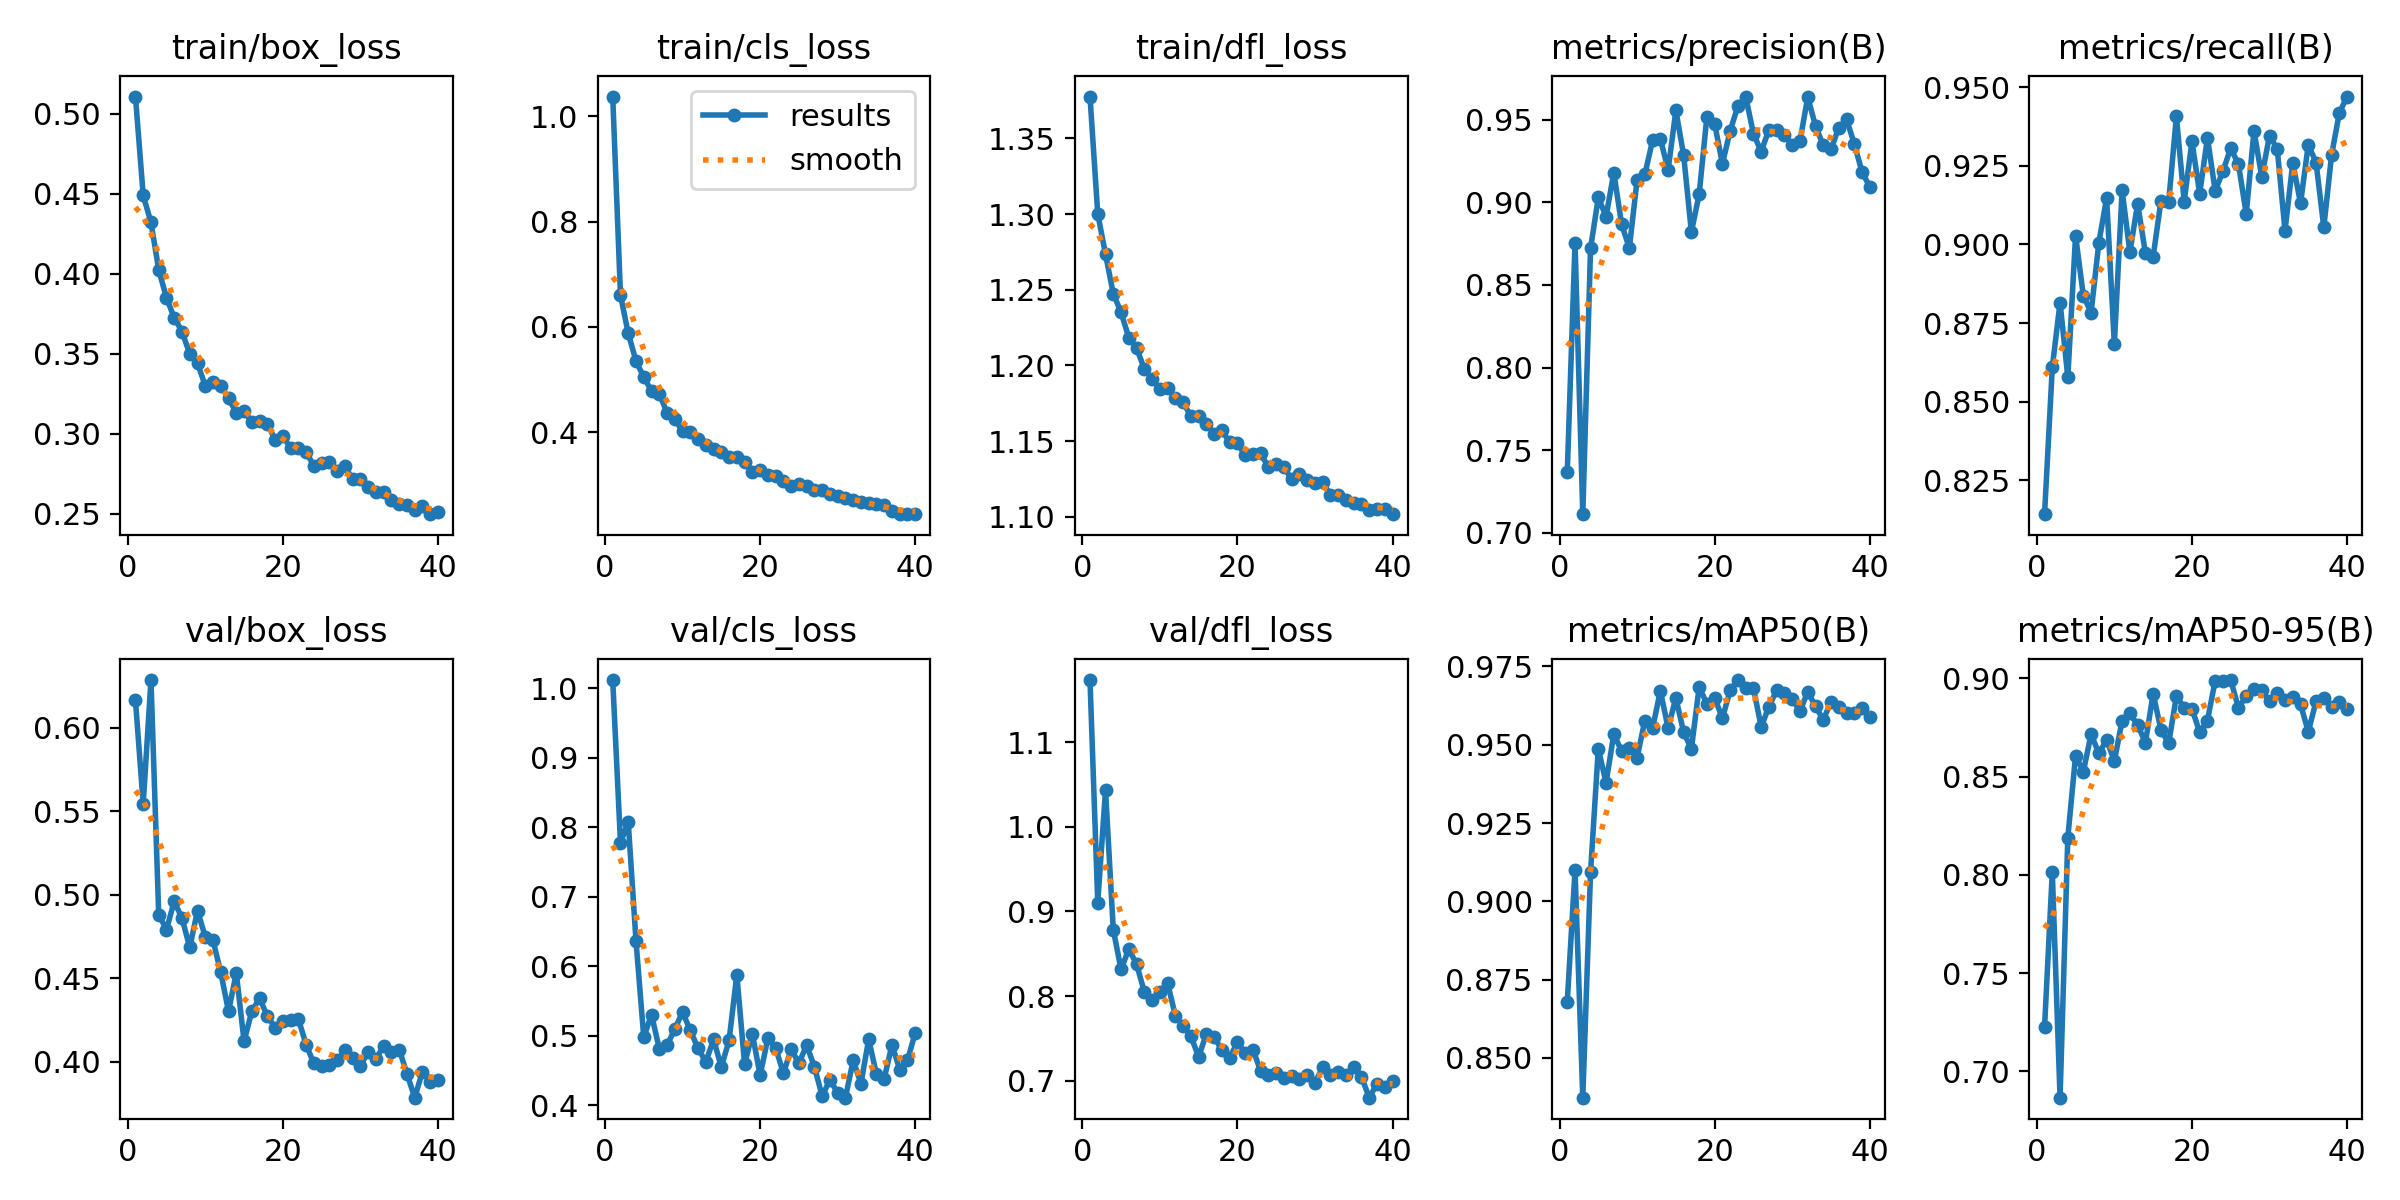

/kaggle/working/corn_yolo_v17_yolov8n/confusion_matrix.png


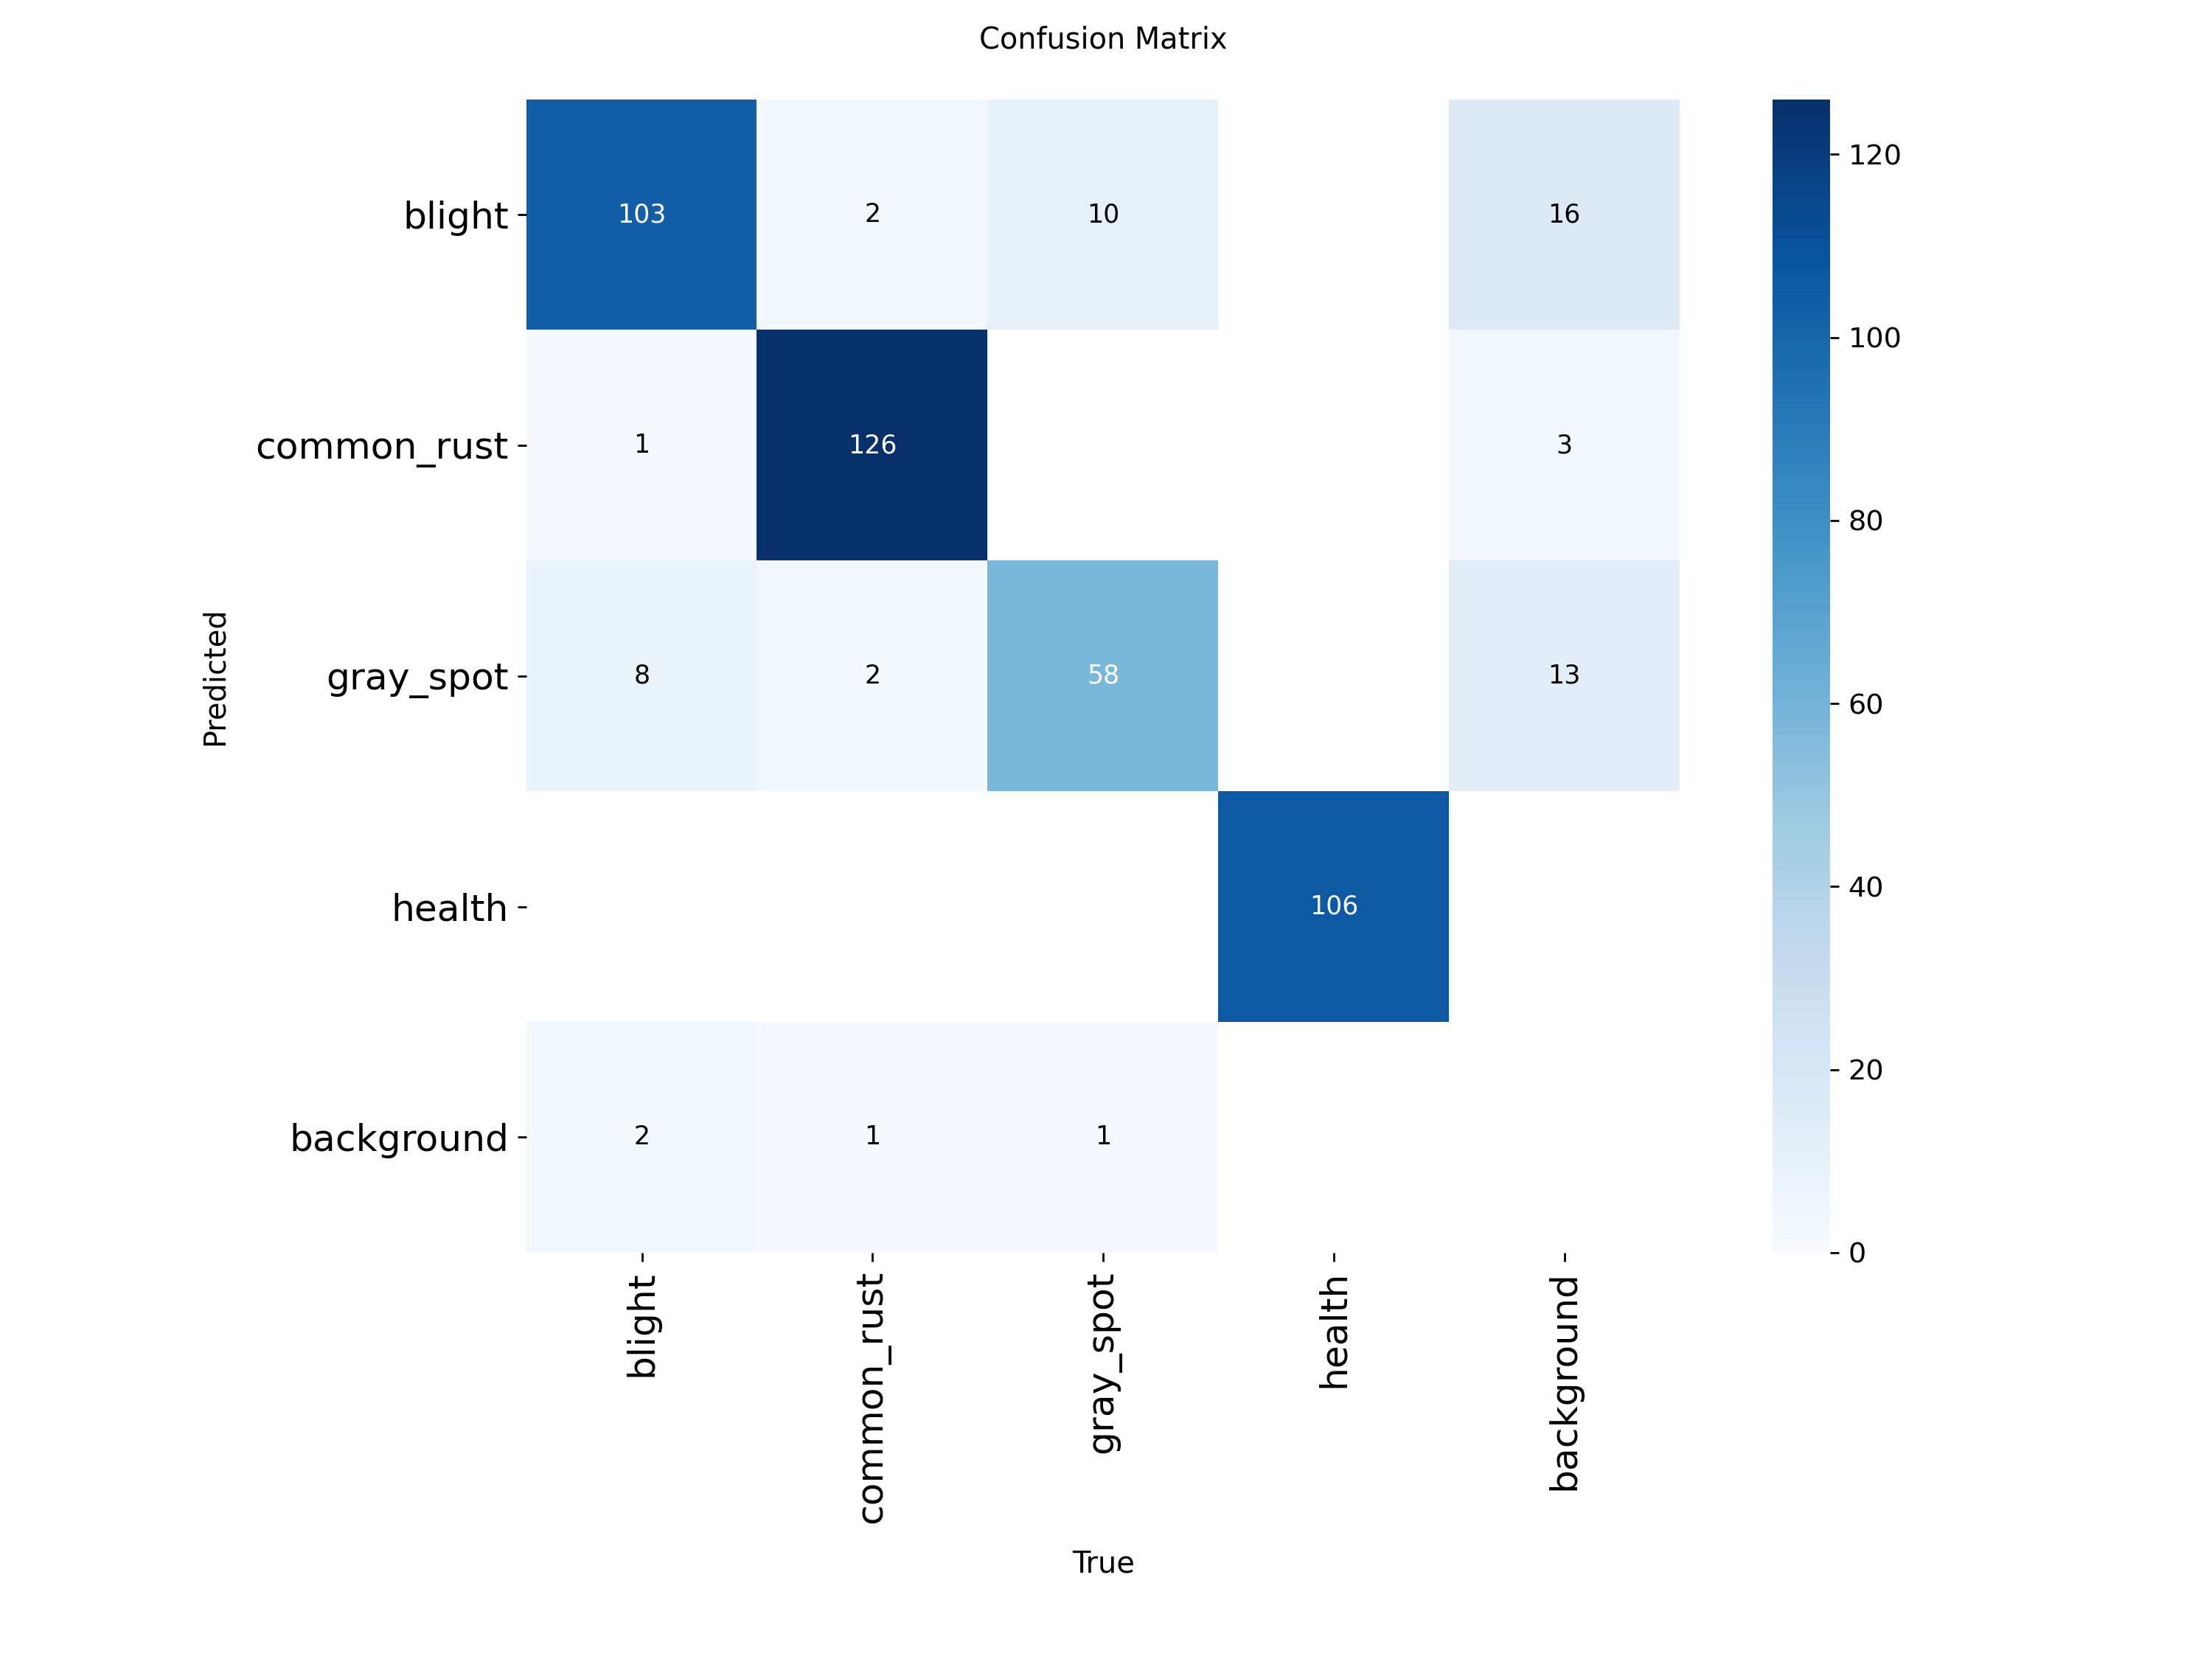

In [8]:
# ===== SHOW RESULT IMAGES =====

from IPython.display import Image, display

result_images = [
    f"/kaggle/working/{MODEL_NAME}/results.png",
    f"/kaggle/working/{MODEL_NAME}/confusion_matrix.png",
    f"/kaggle/working/{MODEL_NAME}/PR_curve.png",
    f"/kaggle/working/{MODEL_NAME}/F1_curve.png"
]

for img_path in result_images:
    if os.path.exists(img_path):
        print(img_path)
        display(Image(filename=img_path))


In [9]:
# ===== PREDICT TEST IMAGES =====

test_dirs = glob.glob(DATASET_PATH + "/**/test/images", recursive=True)

if len(test_dirs) > 0:
    TEST_IMAGES = test_dirs[0]
elif os.path.exists(os.path.join(DATASET_PATH, "valid/images")):
    TEST_IMAGES = os.path.join(DATASET_PATH, "valid/images")
else:
    TEST_IMAGES = os.path.join(DATASET_PATH, "val/images")

print("Using predict source:", TEST_IMAGES)

predict_results = best_model.predict(
    source=TEST_IMAGES,
    conf=0.25,
    save=True,
    project="/kaggle/working",
    name="predict_v17_test",
    exist_ok=True
)

print("Prediction saved to: /kaggle/working/predict_v17_test")


Using predict source: /kaggle/working/Corn-Leaf-Disease-17/test/images

image 1/417 /kaggle/working/Corn-Leaf-Disease-17/test/images/Corn_Blight-1001-_JPG.rf.892a07c42ad930d4ba32a7aff8f41692.jpg: 640x640 1 blight, 7.1ms
image 2/417 /kaggle/working/Corn-Leaf-Disease-17/test/images/Corn_Blight-1008-_JPG.rf.d63b9c756a3453f0b2b417ac623d2914.jpg: 640x640 1 blight, 7.5ms
image 3/417 /kaggle/working/Corn-Leaf-Disease-17/test/images/Corn_Blight-1014-_JPG.rf.f2baea40c441c9eed1c465736ef1a393.jpg: 640x640 1 blight, 7.1ms
image 4/417 /kaggle/working/Corn-Leaf-Disease-17/test/images/Corn_Blight-1018-_jpg.rf.8763a48b1081e05863150bbde5fe0a7b.jpg: 640x640 1 blight, 7.1ms
image 5/417 /kaggle/working/Corn-Leaf-Disease-17/test/images/Corn_Blight-1022-_JPG.rf.7fa6af287e8e9ed07d256e03b64984ab.jpg: 640x640 1 blight, 7.1ms
image 6/417 /kaggle/working/Corn-Leaf-Disease-17/test/images/Corn_Blight-1030-_jpg.rf.83e2c5f9664a18a8ddbe73ba95da495b.jpg: 640x640 1 blight, 7.1ms
image 7/417 /kaggle/working/Corn-Leaf-Di

Pred images: 417


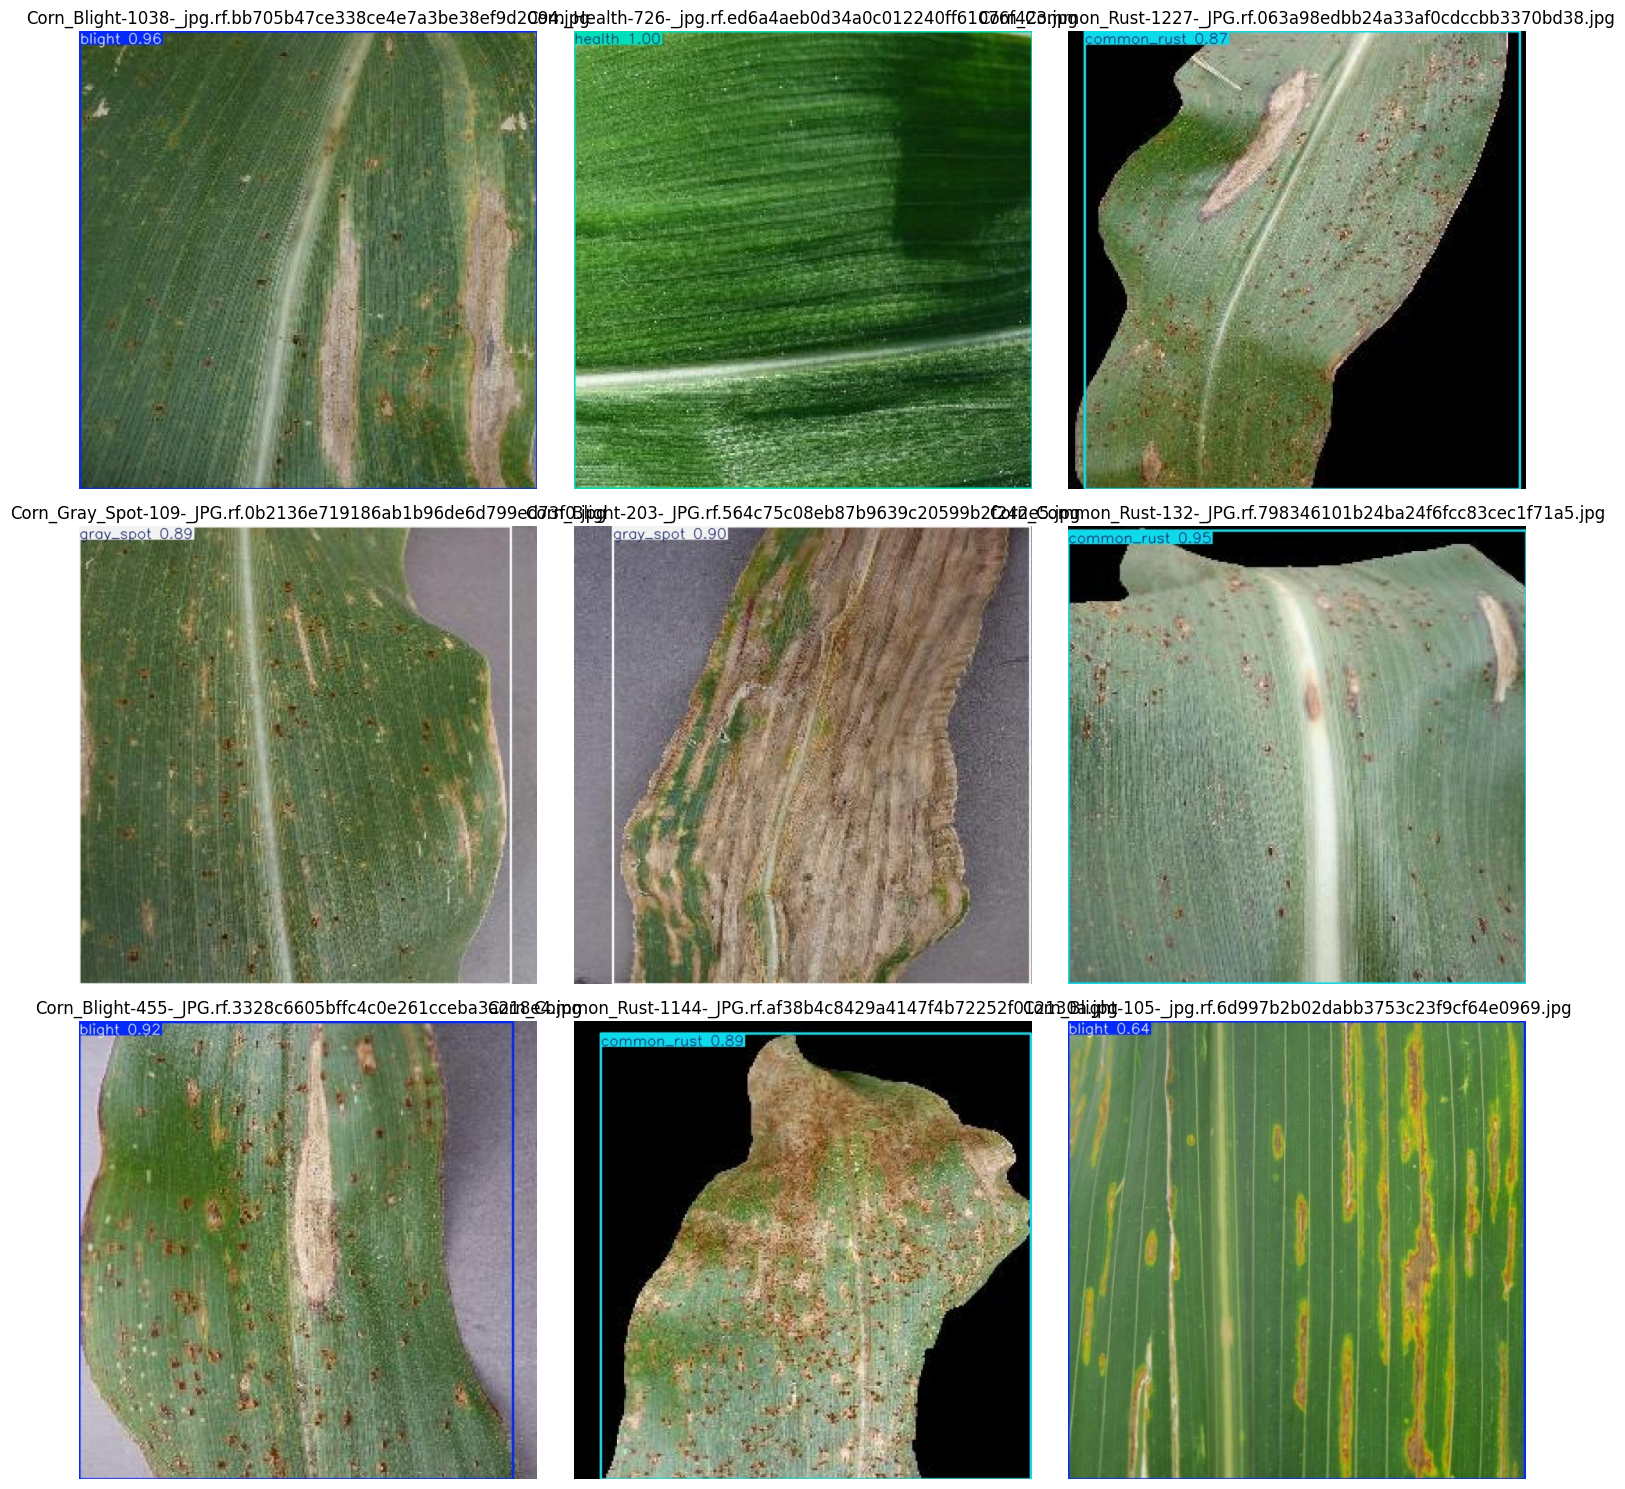

In [10]:
# ===== SHOW SOME PREDICTION IMAGES =====

from PIL import Image as PILImage
import matplotlib.pyplot as plt

pred_dir = "/kaggle/working/predict_v17_test"

pred_images = []
for ext in ["*.jpg", "*.jpeg", "*.png"]:
    pred_images += glob.glob(os.path.join(pred_dir, ext))

print("Pred images:", len(pred_images))

sample = pred_images[:9]

plt.figure(figsize=(15, 15))

for i, img_path in enumerate(sample):
    img = PILImage.open(img_path).convert("RGB")
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(img_path))
    plt.axis("off")

plt.tight_layout()
plt.show()


In [11]:
# ===== COPY BEST.PT TO WORKING =====

FINAL_BEST = "/kaggle/working/best_yolo_v17.pt"

shutil.copy(BEST_MODEL_PATH, FINAL_BEST)

print("Saved:", FINAL_BEST)
print("Size MB:", os.path.getsize(FINAL_BEST) / 1024 / 1024)


Saved: /kaggle/working/best_yolo_v17.pt
Size MB: 5.959756851196289


In [12]:
# ===== ZIP TRAIN RESULTS =====

RESULT_DIR = f"/kaggle/working/{MODEL_NAME}"
ZIP_PATH = f"/kaggle/working/{MODEL_NAME}_results.zip"

shutil.make_archive(
    ZIP_PATH.replace(".zip", ""),
    "zip",
    RESULT_DIR
)

print("Saved:", ZIP_PATH)


Saved: /kaggle/working/corn_yolo_v17_yolov8n_results.zip


In [13]:
# ===== OPTIONAL: TRAIN YOLOv8s IF YOU STILL HAVE TIME =====
# Chỉ chạy nếu YOLOv8n chưa đủ tốt và bạn còn thời gian.

# MODEL_NAME_S = "corn_yolo_v17_yolov8s"
# model_s = YOLO("yolov8s.pt")
#
# results_s = model_s.train(
#     data=FIXED_YAML,
#     epochs=80,
#     imgsz=640,
#     batch=16,
#     patience=15,
#     device=0,
#     project="/kaggle/working",
#     name=MODEL_NAME_S,
#     exist_ok=True,
#     optimizer="AdamW",
#     lr0=0.001,
#     hsv_h=0.01,
#     hsv_s=0.25,
#     hsv_v=0.15,
#     degrees=0,
#     translate=0.03,
#     scale=0.15,
#     fliplr=0.5,
#     mosaic=0.1,
#     mixup=0.0,
#     close_mosaic=10,
#     save=True,
#     plots=True
# )
